## Task 1: Apply Principal Component Analysis (PCA) for feature extraction and dimensionality reduction
*Suggested Dataset: Iris Dataset*


### Subtask 1.1: Data Acquisition and Feature Standardization
**Concept:** Import warnings suppression and libraries, load the taxonomic Iris dataset, and standardize the feature space using StandardScaler.


In [263]:
import warnings

In [265]:
warnings.filterwarnings("ignore")

In [266]:
import pandas as pd

In [268]:
import numpy as np

In [269]:
from sklearn.datasets import load_iris

In [270]:
from sklearn.preprocessing import StandardScaler

In [272]:
raw_iris = load_iris()

In [273]:
features = raw_iris.feature_names

In [274]:
X_raw = raw_iris.data

In [275]:
y_true = raw_iris.target

In [276]:
scaler = StandardScaler()

In [277]:
X_scaled = scaler.fit_transform(X_raw)

In [278]:
iris_df = pd.DataFrame(data=X_scaled, columns=features)

In [279]:
iris_df['species_id'] = y_true

In [280]:
species_map = {i: name for i, name in enumerate(raw_iris.target_names)}

In [281]:
iris_df['species_name'] = iris_df['species_id'].map(species_map)

In [282]:
print("Standardized dataset dimensions:", X_scaled.shape)

Standardized dataset dimensions: (150, 4)


In [285]:
print("\nFirst 3 rows of standardized dataset:")


First 3 rows of standardized dataset:


In [286]:
print(iris_df.head(3))

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0          -0.900681          1.019004          -1.340227         -1.315444   
1          -1.143017         -0.131979          -1.340227         -1.315444   
2          -1.385353          0.328414          -1.397064         -1.315444   

   species_id species_name  
0           0       setosa  
1           0       setosa  
2           0       setosa  


### Subtask 1.2: Covariance Matrix and Eigenvalue Decomposition
**Concept:** Compute the covariance matrix of the standardized features, then calculate its eigenvalues and eigenvectors to understand PCA's mathematical foundation.


In [288]:
cov_matrix = np.cov(X_scaled.T)

In [289]:
print("Covariance Matrix:\n", cov_matrix)

Covariance Matrix:
 [[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]


In [290]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

In [291]:
print("\nEigenvalues (Variance components):\n", eigenvalues)


Eigenvalues (Variance components):
 [2.93808505 0.9201649  0.14774182 0.02085386]


In [292]:
print("\nEigenvectors (Principal Axes):\n", eigenvectors)


Eigenvectors (Principal Axes):
 [[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]


### Subtask 1.3: Implementing Dimensionality Reduction via PCA
**Concept:** Apply Scikit-Learn's PCA model to project the 4D standardized feature space into 2 principal components.


In [294]:
from sklearn.decomposition import PCA

In [295]:
pca_model = PCA(n_components=2, random_state=42)

In [297]:
X_pca = pca_model.fit_transform(X_scaled)

In [298]:
pca_df = pd.DataFrame(data=X_pca, columns=['PC_1', 'PC2'])

In [299]:
pca_df['species_name'] = iris_df['species_name']

In [300]:
print("Transformed PCA space dimensions:", X_pca.shape)

Transformed PCA space dimensions: (150, 2)


In [301]:
print("\nFirst 3 projected coordinates:")


First 3 projected coordinates:


In [303]:
print(pca_df.head(3))

       PC_1       PC2 species_name
0 -2.264703  0.480027       setosa
1 -2.080961 -0.674134       setosa
2 -2.364229 -0.341908       setosa


### Subtask 1.4: Visualizing the 2D PCA Feature Space
**Concept:** Plot the projected 2D coordinates on a scatter plot, coloring points by their true species labels to check class separation.


In [306]:
import matplotlib.pyplot as plt
import seaborn as sns

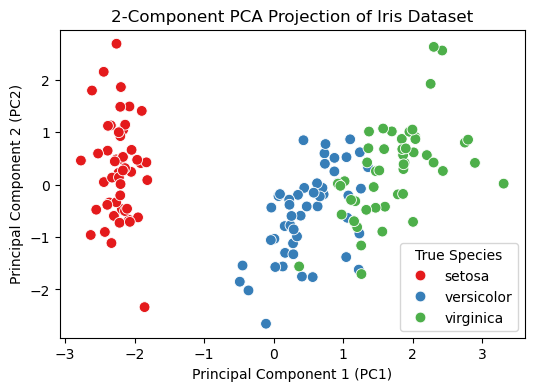

In [307]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=pca_df, x='PC_1', y='PC2', hue='species_name', palette='Set1', s=60)
plt.title("2-Component PCA Projection of Iris Dataset")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend(title='True Species')
plt.show()

### Subtask 1.5: Analyzing Explained Variance Ratio
**Concept:** Extract and print the explained variance ratio of each principal component to quantify how much information is retained in the 2D projection.


In [310]:
explained_variance = pca_model.explained_variance_ratio_

In [312]:
cumulative_variance = np.sum(explained_variance)

In [313]:
print("Explained Variance per Component:")

Explained Variance per Component:


In [314]:
for i, var in enumerate(explained_variance):
    print(f"  PC{i+1}: {var*100:.2f}%")

  PC1: 72.96%
  PC2: 22.85%


In [315]:
print(f"\nTotal Cumulative Variance Retained by 2 Components: {cumulative_variance*100:.2f}%")


Total Cumulative Variance Retained by 2 Components: 95.81%


In [316]:
# ============================================================
# Classification with and without PCA
# Dataset: Iris Dataset
# Classifier: Logistic Regression
# ============================================================


In [317]:
# Step 1: Import required libraries
import numpy as np

In [318]:
import pandas as pd

In [320]:
import matplotlib.pyplot as plt

In [321]:
from sklearn.datasets import load_iris

In [323]:
from sklearn.model_selection import train_test_split

In [324]:
from sklearn.preprocessing import StandardScaler

In [326]:
from sklearn.decomposition import PCA

In [327]:
from sklearn.linear_model import LogisticRegression

In [328]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [330]:
# Step 2: Load the Dataset

In [331]:
iris = load_iris()

In [332]:
X = iris.data                 

In [333]:
y = iris.target

In [335]:
feature_names = iris.feature_names

In [336]:
target_names = iris.target_names

In [337]:
print("Dataset Shape:", X.shape)

Dataset Shape: (150, 4)


In [338]:
 print("Features:", feature_names)

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [339]:
print("Classes:", target_names)

Classes: ['setosa' 'versicolor' 'virginica']


In [341]:
# Step 3: Split the Dataset

In [342]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [343]:
# Step 4: Feature Scaling

In [344]:
scaler = StandardScaler()

In [346]:
X_train_scaled = scaler.fit_transform(X_train)

In [347]:
X_test_scaled = scaler.transform(X_test)

In [348]:
# PART A: CLASSIFICATION WITHOUT PCA

In [349]:
print("===== CLASSIFICATION WITH PCA ==== ")


===== CLASSIFICATION WITH PCA ==== 


In [350]:
pca = PCA(n_components=2)

In [351]:
# Fit PCA only on training data

In [352]:
X_train_pca = pca.fit_transform(X_train_scaled)

In [353]:
X_test_pca = pca.transform(X_test_scaled)

In [354]:
print("Explained Variance Ratio:",pca.explained_variance_ratio_)

Explained Variance Ratio: [0.72677234 0.23066667]


In [355]:
print("Total Explained Variance:",pca.explained_variance_ratio_.sum())

Total Explained Variance: 0.9574390106545367


In [356]:
model_with_pca = LogisticRegression(random_state=42,max_iter=1000)


In [357]:
model_with_pca.fit(X_train_pca,y_train)


LogisticRegression(max_iter=1000, random_state=42)

In [358]:
y_pred_with_pca = model_with_pca.predict(X_test_pca)

In [359]:
accuracy_with_pca = accuracy_score(y_test,y_pred_with_pca)

In [360]:
print("Accuracy with PCA:",accuracy_with_pca)

Accuracy with PCA: 0.9


In [361]:
print("\nClassification Report:")


Classification Report:


In [362]:
print(classification_report( y_test,y_pred_with_pca,target_names=target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



In [363]:
# PART C: COMPARE BOTH MODELS

In [364]:
print("== COMPARISON ===")

== COMPARISON ===


In [365]:
comparison = pd.DataFrame({
    "Method": [
        "Without PCA",
        "With PCA"
    ],
    "Number of Features": [
        X_train_scaled.shape[1],
        X_train_pca.shape[1]
    ],
    "Accuracy": [
        accuracy_without_pca,
        accuracy_with_pca
    ]
})


NameError: name 'accuracy_without_pca' is not defined